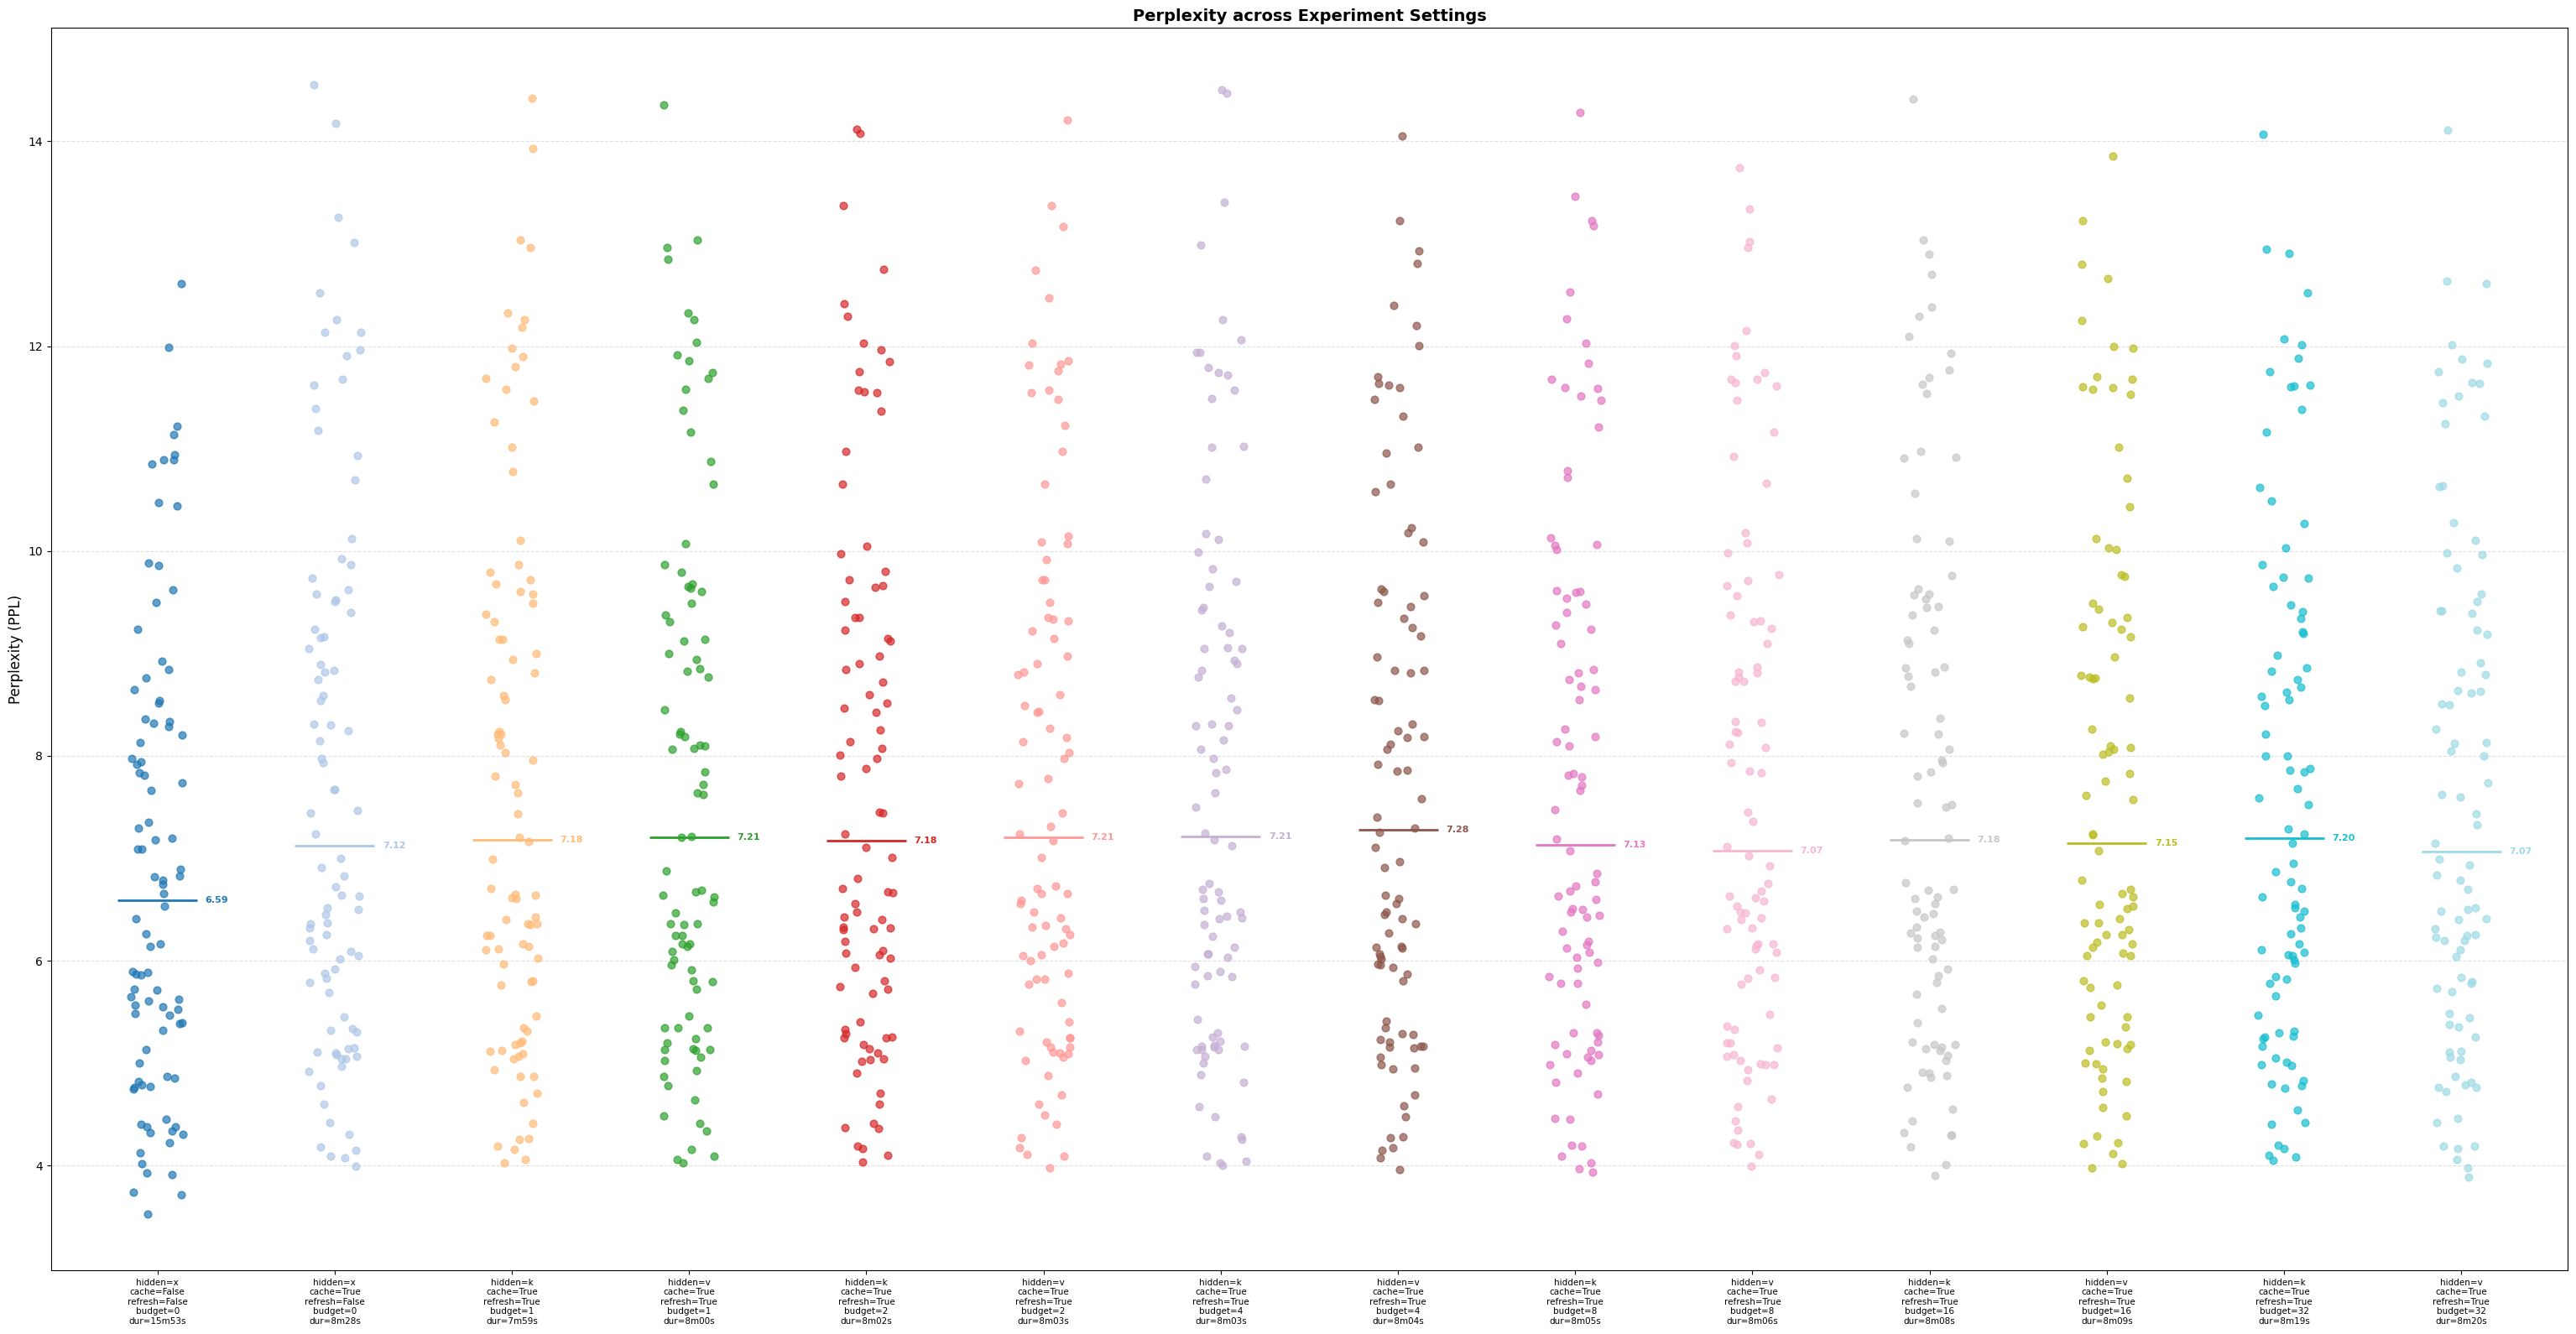

In [ ]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime

# ── Config ───────────────────────────────────────────────────────────────────
DATA_DIR      = "ppl_result"     # folder containing the data files
JITTER_AMOUNT = 0.15    # how much to scatter points horizontally
POINT_ALPHA   = 0.7
POINT_SIZE    = 40
# ─────────────────────────────────────────────────────────────────────────────

FILE_PATTERN = re.compile(
    r"hidden_(?P<hidden_type>.+?)_cache_(?P<use_cache>.+?)_refresh_(?P<use_refresh>.+?)_budget_(?P<refresh_budget>.+?)$"
)
LINE_PATTERN = re.compile(
    r"\[(?P<timestamp>[^\]]+)\]\s+(?P<ppl>[\d.]+)\s*\|\s*(?P<conf>[\d.]+)"
)
TS_FORMATS = [
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%dT%H:%M:%SZ",
    "%H:%M:%S",
    "%Y/%m/%d %H:%M:%S",
]


def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0]
    m = FILE_PATTERN.match(name)
    return m.groupdict() if m else None


def parse_timestamp(ts_str):
    for fmt in TS_FORMATS:
        try:
            return datetime.strptime(ts_str.strip(), fmt)
        except ValueError:
            continue
    return None


def parse_file(path):
    """Returns (ppls, duration_seconds).
    duration = last_timestamp - first_timestamp in the file.
    """
    ppls, timestamps = [], []
    with open(path, "r") as f:
        for line in f:
            m = LINE_PATTERN.search(line.strip())
            if m:
                ppls.append(float(m.group("ppl")))
                ts = parse_timestamp(m.group("timestamp"))
                if ts:
                    timestamps.append(ts)

    duration = None
    if len(timestamps) >= 2:
        duration = (timestamps[-1] - timestamps[0]).total_seconds()
    return ppls, duration


def format_duration(seconds):
    if seconds is None:
        return "N/A"
    seconds = int(seconds)
    h, rem = divmod(seconds, 3600)
    m, s   = divmod(rem, 60)
    if h > 0:
        return f"{h}h{m:02d}m{s:02d}s"
    elif m > 0:
        return f"{m}m{s:02d}s"
    else:
        return f"{s}s"


def build_label(params, avg_duration=None):
    dur_str = format_duration(avg_duration)
    return (
        f"hidden={params['hidden_type']}\n"
        f"cache={params['use_cache']}\n"
        f"refresh={params['use_refresh']}\n"
        f"budget={params['refresh_budget']}\n"
        f"dur={dur_str}"
    )


def main():
    files = sorted(
        glob.glob(os.path.join(DATA_DIR, "hidden_*_cache_*_refresh_*_budget_*"))
    )
    if not files:
        print(f"No matching files found in '{DATA_DIR}'.")
        return

    # settings_key -> list of ppls / durations
    groups    = {}
    param_map = {}
    durations = {}

    for path in files:
        params = parse_filename(path)
        if params is None:
            print(f"  Skipping (unrecognised filename): {path}")
            continue
        ppls, duration = parse_file(path)
        if not ppls:
            print(f"  Skipping (no data): {path}")
            continue

        key = (
            params["hidden_type"], params["use_cache"],
            params["use_refresh"], params["refresh_budget"],
        )
        groups.setdefault(key, []).extend(ppls)
        param_map[key] = params
        durations.setdefault(key, [])
        if duration is not None:
            durations[key].append(duration)

    if not groups:
        print("No data parsed. Check file names and content format.")
        return

    # Sort by budget
    def budget_sort_key(key):
        try:
            return float(param_map[key]["refresh_budget"])
        except ValueError:
            return param_map[key]["refresh_budget"]

    sorted_keys = sorted(groups.keys(), key=budget_sort_key)

    # Build display labels (average duration across files with same setting)
    labels = []
    for key in sorted_keys:
        dur_list = durations.get(key, [])
        avg_dur  = sum(dur_list) / len(dur_list) if dur_list else None
        labels.append(build_label(param_map[key], avg_dur))

    x_pos   = np.arange(len(sorted_keys))

    # Colour map: one colour per setting
    colours = cm.tab20(np.linspace(0, 1, len(sorted_keys)))

    fig, ax = plt.subplots(figsize=(max(10, len(sorted_keys) * 2.2), 16))

    for i, key in enumerate(sorted_keys):
        ppls   = groups[key]
        n      = len(ppls)
        jitter = np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=n)
        x_jit  = x_pos[i] + jitter

        ax.scatter(
            x_jit, ppls,
            color=colours[i],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

        # Median line
        median_val = np.median(ppls)
        ax.hlines(
            median_val,
            x_pos[i] - JITTER_AMOUNT * 1.5,
            x_pos[i] + JITTER_AMOUNT * 1.5,
            colors=colours[i],
            linewidths=2,
            zorder=4,
        )

        # Median value label next to the line
        ax.text(
            x_pos[i] + JITTER_AMOUNT * 1.8,
            median_val,
            f"{median_val:.2f}",
            ha="left", va="center", fontsize=8,
            color=colours[i], fontweight="bold",
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=7.5, ha="center")
    ax.set_ylabel("Perplexity (PPL)", fontsize=12)
    ax.set_title("Perplexity across Experiment Settings", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_xlim(-0.6, len(sorted_keys) - 0.4)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    np.random.seed(42)
    main()

Plot saved to: ppl_result_randomed/ppl_plot.png


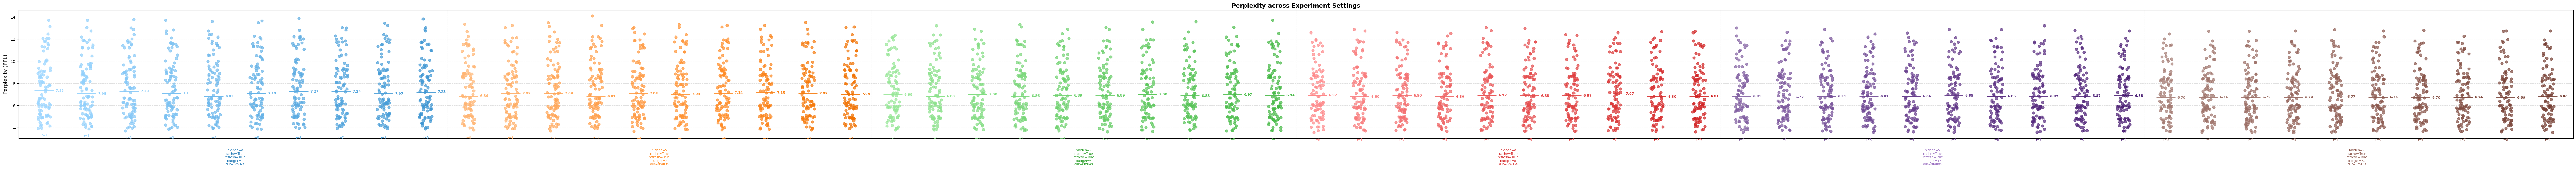

In [ ]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from datetime import datetime

# ── Config ───────────────────────────────────────────────────────────────────
DATA_DIR      = "ppl_result_randomed"     # folder containing the data files
JITTER_AMOUNT = 0.15    # how much to scatter points horizontally
POINT_ALPHA   = 0.7
POINT_SIZE    = 40
# ─────────────────────────────────────────────────────────────────────────────

# Matches both:
#   hidden_{h}_cache_{c}_refresh_{r}_budget_{b}
#   hidden_{h}_cache_{c}_refresh_{r}_budget_{b}_randomed_{i}.report
FILE_PATTERN = re.compile(
    r"hidden_(?P<hidden_type>.+?)_cache_(?P<use_cache>.+?)_refresh_(?P<use_refresh>.+?)_budget_(?P<refresh_budget>.+?)"
    r"(?:_randomed_(?P<rand_i>.+?))?(?:\.report)?$"
)
LINE_PATTERN = re.compile(
    r"\[(?P<timestamp>[^\]]+)\]\s+(?P<ppl>[\d.]+)\s*\|\s*(?P<conf>[\d.]+)"
)
TS_FORMATS = [
    "%Y-%m-%d %H:%M:%S",
    "%Y-%m-%dT%H:%M:%SZ",
    "%H:%M:%S",
    "%Y/%m/%d %H:%M:%S",
]


def parse_filename(path):
    name = os.path.basename(path)
    # Strip .report extension before matching if present
    if name.endswith(".report"):
        name = name[:-7]
    m = FILE_PATTERN.match(name)
    if not m:
        return None
    d = m.groupdict()
    d["rand_i"] = d["rand_i"]  # may be None
    return d


def parse_timestamp(ts_str):
    for fmt in TS_FORMATS:
        try:
            return datetime.strptime(ts_str.strip(), fmt)
        except ValueError:
            continue
    return None


def parse_file(path):
    """Returns (ppls, duration_seconds)."""
    ppls, timestamps = [], []
    with open(path, "r") as f:
        for line in f:
            m = LINE_PATTERN.search(line.strip())
            if m:
                ppls.append(float(m.group("ppl")))
                ts = parse_timestamp(m.group("timestamp"))
                if ts:
                    timestamps.append(ts)
    duration = None
    if len(timestamps) >= 2:
        duration = (timestamps[-1] - timestamps[0]).total_seconds()
    return ppls, duration


def format_duration(seconds):
    if seconds is None:
        return "N/A"
    seconds = int(seconds)
    h, rem = divmod(seconds, 3600)
    m, s   = divmod(rem, 60)
    if h > 0:
        return f"{h}h{m:02d}m{s:02d}s"
    elif m > 0:
        return f"{m}m{s:02d}s"
    else:
        return f"{s}s"


def build_label(params, avg_duration=None):
    dur_str = format_duration(avg_duration)
    return (
        f"hidden={params['hidden_type']}\n"
        f"cache={params['use_cache']}\n"
        f"refresh={params['use_refresh']}\n"
        f"budget={params['refresh_budget']}\n"
        f"dur={dur_str}"
    )


def vary_color(base_rgba, n_variants, idx):
    """Return a lightness-varied version of base_rgba for variant idx/n_variants."""
    if n_variants <= 1:
        return base_rgba
    r, g, b, a = base_rgba
    h, l, s = mcolors.rgb_to_hsv((r, g, b))
    # Vary value (brightness) from 0.5x to 1.0x of original
    factor = 0.55 + 0.45 * (idx / (n_variants - 1))
    r2, g2, b2 = mcolors.hsv_to_rgb((h, s * factor, min(1.0, l + (1 - factor) * 0.4)))
    return (r2, g2, b2, a)


def main():
    files = sorted(
        glob.glob(os.path.join(DATA_DIR, "hidden_*_cache_*_refresh_*_budget_*"))
    )
    if not files:
        print(f"No matching files found in '{DATA_DIR}'.")
        return

    # setting_key -> { rand_i -> {ppls, durations} }
    runs      = {}   # setting_key -> dict of rand_i -> list of ppls
    durations = {}   # setting_key -> dict of rand_i -> list of durations
    param_map = {}   # setting_key -> params

    for path in files:
        params = parse_filename(path)
        if params is None:
            print(f"  Skipping (unrecognised filename): {path}")
            continue
        ppls, duration = parse_file(path)
        if not ppls:
            print(f"  Skipping (no data): {path}")
            continue

        setting_key = (
            params["hidden_type"], params["use_cache"],
            params["use_refresh"], params["refresh_budget"],
        )
        rand_i = params["rand_i"] if params["rand_i"] is not None else "__default__"

        runs.setdefault(setting_key, {}).setdefault(rand_i, []).extend(ppls)
        durations.setdefault(setting_key, {}).setdefault(rand_i, [])
        if duration is not None:
            durations[setting_key][rand_i].append(duration)
        param_map[setting_key] = params

    if not runs:
        print("No data parsed. Check file names and content format.")
        return

    # Sort settings by budget
    def budget_sort_key(key):
        try:
            return float(param_map[key]["refresh_budget"])
        except ValueError:
            return param_map[key]["refresh_budget"]

    sorted_settings = sorted(runs.keys(), key=budget_sort_key)

    # Build column list: one column per (setting, rand_i), grouped by setting
    columns = []  # list of (setting_key, rand_i)
    for sk in sorted_settings:
        rand_keys = sorted(runs[sk].keys(), key=lambda r: (r == "__default__", r))
        for rk in rand_keys:
            columns.append((sk, rk))

    x_pos = np.arange(len(columns))

    # Base colour per setting (one from tab10)
    base_cmap   = cm.tab10
    setting_idx = {sk: i for i, sk in enumerate(sorted_settings)}
    base_colours = [base_cmap(setting_idx[sk] % 10) for sk in sorted_settings]

    # Pre-compute per-column colours with lightness variation within a setting
    def get_col_colour(setting_key, rand_i):
        base   = base_colours[setting_idx[setting_key]]
        rand_keys = sorted(runs[setting_key].keys(), key=lambda r: (r == "__default__", r))
        n      = len(rand_keys)
        idx    = rand_keys.index(rand_i)
        return vary_color(base, n, idx)

    # Build x-axis labels (per setting, shared across its rand columns)
    # We'll write the setting label once centred over its group of columns
    fig, ax = plt.subplots(figsize=(max(10, len(columns) * 1.8), 16))

    for col_i, (sk, rk) in enumerate(columns):
        ppls   = runs[sk][rk]
        colour = get_col_colour(sk, rk)
        n      = len(ppls)
        jitter = np.random.uniform(-JITTER_AMOUNT, JITTER_AMOUNT, size=n)
        x_jit  = x_pos[col_i] + jitter

        run_label = "" if rk == "__default__" else f"run {rk}"
        ax.scatter(
            x_jit, ppls,
            color=colour,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
            label=run_label,
        )

        median_val = np.median(ppls)
        ax.hlines(
            median_val,
            x_pos[col_i] - JITTER_AMOUNT * 1.5,
            x_pos[col_i] + JITTER_AMOUNT * 1.5,
            colors=colour,
            linewidths=2,
            zorder=4,
        )
        ax.text(
            x_pos[col_i] + JITTER_AMOUNT * 1.8,
            median_val,
            f"{median_val:.2f}",
            ha="left", va="center", fontsize=8,
            color=colour, fontweight="bold",
        )

        # Label run index below the column
        if rk != "__default__":
            ax.text(
                x_pos[col_i], ax.get_ylim()[0],
                f"r={rk}", ha="center", va="top",
                fontsize=7, color=colour,
            )

    # Draw setting group labels + separators
    col_setting = [sk for sk, rk in columns]
    i = 0
    while i < len(columns):
        sk = col_setting[i]
        j  = i
        while j < len(columns) and col_setting[j] == sk:
            j += 1
        # columns i..j-1 belong to this setting
        center_x = (x_pos[i] + x_pos[j - 1]) / 2

        dur_list = [d for rk in durations[sk] for d in durations[sk][rk]]
        avg_dur  = sum(dur_list) / len(dur_list) if dur_list else None
        label    = build_label(param_map[sk], avg_dur)

        ax.text(
            center_x, -0.08, label,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=7.5,
            color=base_colours[setting_idx[sk]],
        )

        # Light vertical separator between setting groups
        if j < len(columns):
            sep_x = (x_pos[j - 1] + x_pos[j]) / 2
            ax.axvline(sep_x, color="gray", linewidth=0.8, linestyle="--", alpha=0.4)

        i = j

    ax.set_xticks([])   # labels drawn manually above
    ax.set_ylabel("Perplexity (PPL)", fontsize=12)
    ax.set_title("Perplexity across Experiment Settings", fontsize=14, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_xlim(-0.6, len(columns) - 0.4)

    plt.subplots_adjust(bottom=0.28)
    plt.show()


if __name__ == "__main__":
    np.random.seed(42)
    main()